# Paper 1 — Figure 1: Whole-Body AD Genetic Risk Atlas


In [1]:
import pandas as pd, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import re, os
%matplotlib inline
plt.rcParams.update({'font.family': 'Arial', 'font.size': 11, 'pdf.fonttype': 42})
BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures/paper1', exist_ok=True)


In [2]:
# Cell 3: Load data
spot = pd.read_csv(f'{BASE}/results/all_organs_spot_AD_pvalues.csv.gz')
spot_ctrl1 = spot[spot['sample'] == 'CTRL_1'].copy()
print(f'Spot data: {len(spot)} rows, CTRL_1: {len(spot_ctrl1)} rows')
print(f'Organs in spot CTRL_1: {sorted(spot_ctrl1["organ"].unique())}')

cauchy = pd.read_csv(f'{BASE}/results/all_organs_cauchy_AD.csv.gz')
print(f'Cauchy data: {len(cauchy)} rows')

age_cauchy = pd.read_csv(f'{BASE}/results/age_all_cauchy_AD.csv.gz')
# Fix organ names: some have organ embedded in sample like 'Brain_18m' in organ col
# Also fix rows where organ and age columns are swapped (e.g., organ='Brain', age='Brain')
bad_rows = age_cauchy['organ'].str.contains(r'_\d', na=False)
if bad_rows.any():
    age_cauchy.loc[bad_rows, 'organ'] = age_cauchy.loc[bad_rows, 'organ'].str.replace(r'_\d+m?$', '', regex=True)
# Fix rows where age column contains the organ name (swap detected)
bad_age = age_cauchy['age'].apply(lambda x: not bool(re.search(r'\d', str(x))))
if bad_age.any():
    print(f'Dropping {bad_age.sum()} rows with non-numeric age values')
    age_cauchy = age_cauchy[~bad_age].copy()
print(f'Age cauchy data: {len(age_cauchy)} rows')
print(f'Age organs: {sorted(age_cauchy["organ"].unique())}')
print(f'Ages: {sorted(age_cauchy["age"].unique())}')


Spot data: 1120354 rows, CTRL_1: 552229 rows
Organs in spot CTRL_1: ['Bone Marrow', 'Brain', 'Brown Fat', 'Colon', 'Heart', 'Kidney', 'Liver', 'Lung', 'Lymph Node', 'Muscle', 'Pancreas', 'Skin', 'Small Intestine', 'Spleen', 'Stomach', 'Thymus']
Cauchy data: 86 rows
Age cauchy data: 1402 rows
Age organs: ['BAT', 'Bone_Marrow', 'Brain', 'Colon', 'Heart', 'Ileum', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Pancreas', 'Skin', 'Spleen', 'Stomach', 'Thymus']
Ages: ['03_months', '06_months', '12_months', '12m', '16_months', '18m', '1m', '21_months', '21m', '23_months', '24m', '30m', '3m', '6m']


Number of organs: 16


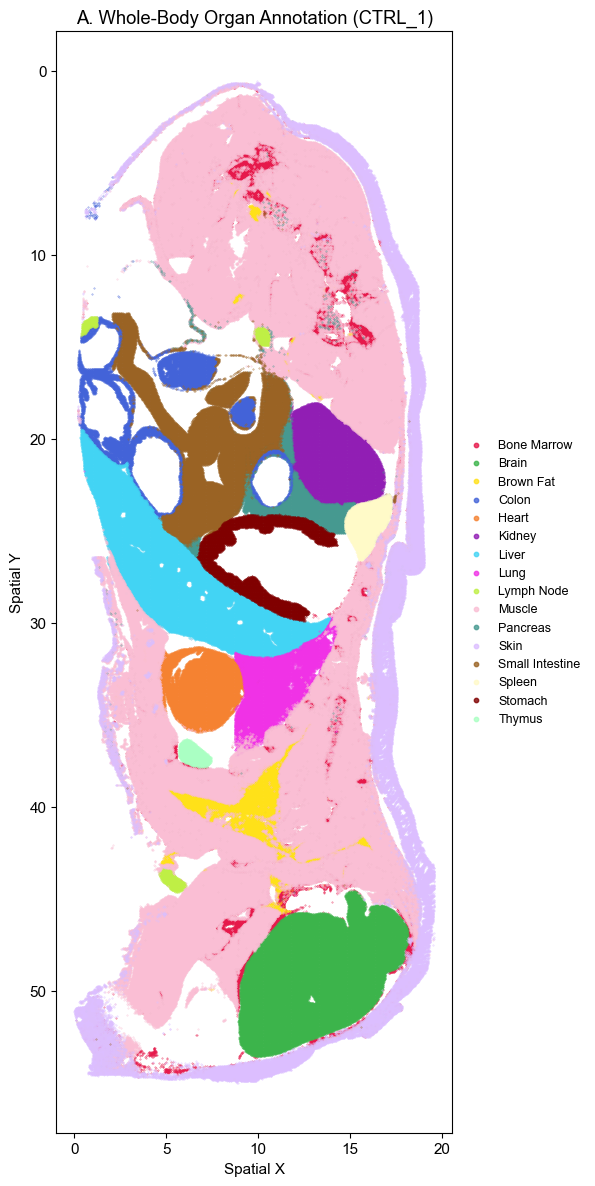

In [3]:
# Cell 4: Panel A — Whole-body organ annotation (CTRL_1)
organs = sorted(spot_ctrl1['organ'].unique())
n_organs = len(organs)
print(f'Number of organs: {n_organs}')

# 16 distinct colors
palette = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4',
    '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000',
    '#aaffc3', '#808000', '#ffd8b1'
]
organ_colors = {org: palette[i % len(palette)] for i, org in enumerate(organs)}

fig, ax = plt.subplots(figsize=(10, 12))
for org in organs:
    sub = spot_ctrl1[spot_ctrl1['organ'] == org]
    ax.scatter(sub['x'], sub['y'], c=organ_colors[org], s=0.1, label=org,
              rasterized=True, alpha=0.8)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_xlabel('Spatial X')
ax.set_ylabel('Spatial Y')
ax.set_title('A. Whole-Body Organ Annotation (CTRL_1)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), markerscale=10, fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1A_organ_annotation.png', dpi=300, bbox_inches='tight')
plt.show()


logp 99th percentile (vmax): 5.15


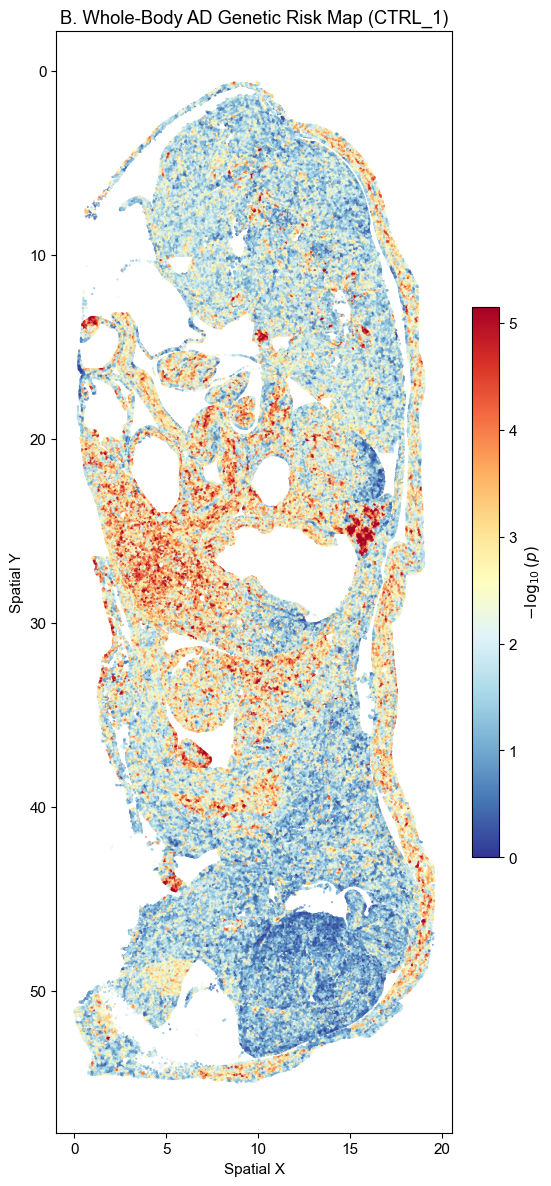

In [4]:
# Cell 5: Panel B — Whole-body AD risk map (CTRL_1)
vmax = np.percentile(spot_ctrl1['logp'].dropna(), 99)
print(f'logp 99th percentile (vmax): {vmax:.2f}')

fig, ax = plt.subplots(figsize=(10, 12))
sc = ax.scatter(spot_ctrl1['x'], spot_ctrl1['y'], c=spot_ctrl1['logp'],
                cmap='RdYlBu_r', s=0.1, vmin=0, vmax=vmax, rasterized=True)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_xlabel('Spatial X')
ax.set_ylabel('Spatial Y')
ax.set_title('B. Whole-Body AD Genetic Risk Map (CTRL_1)')
cbar = plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('$-\\log_{10}(p)$')
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1B_risk_map.png', dpi=300, bbox_inches='tight')
plt.show()


Bonferroni threshold (-log10(0.05/16)): 2.51


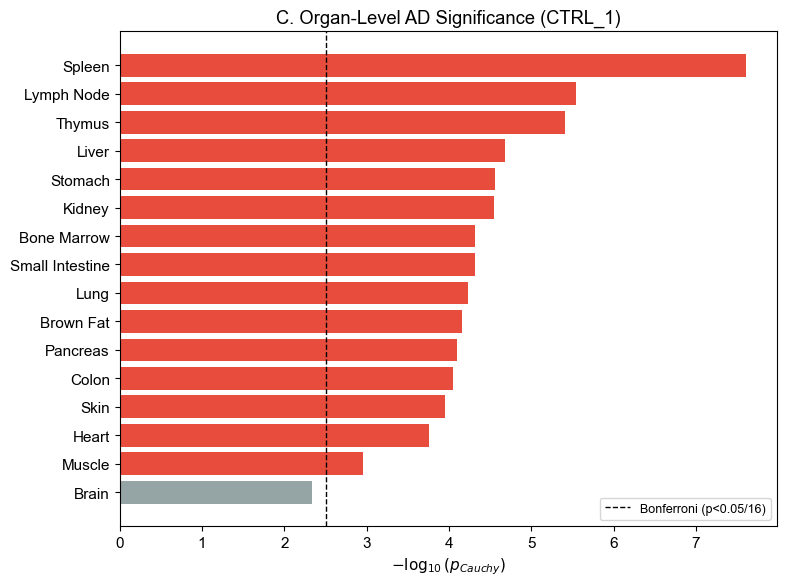

In [5]:
# Cell 6: Panel C — Organ-level Cauchy barplot (CTRL_1)
cauchy_ctrl1 = cauchy[cauchy['sample'] == 'CTRL_1'].copy()
organ_min_p = cauchy_ctrl1.groupby('organ')['p_cauchy'].min().reset_index()
organ_min_p['logp'] = -np.log10(organ_min_p['p_cauchy'])
organ_min_p = organ_min_p.sort_values('logp', ascending=True)

n_organs_cauchy = len(organ_min_p)
bonf_thresh = -np.log10(0.05 / n_organs_cauchy)
print(f'Bonferroni threshold (-log10(0.05/{n_organs_cauchy})): {bonf_thresh:.2f}')

colors = ['#e74c3c' if lp >= bonf_thresh else '#95a5a6' for lp in organ_min_p['logp']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(organ_min_p['organ'], organ_min_p['logp'], color=colors)
ax.axvline(bonf_thresh, color='black', linestyle='--', linewidth=1,
           label=f'Bonferroni (p<0.05/{n_organs_cauchy})')
ax.set_xlabel('$-\\log_{10}(p_{Cauchy})$')
ax.set_title('C. Organ-Level AD Significance (CTRL_1)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1C_organ_barplot.png', dpi=300, bbox_inches='tight')
plt.show()


Pearson r = 0.917, p = 6.03e-07


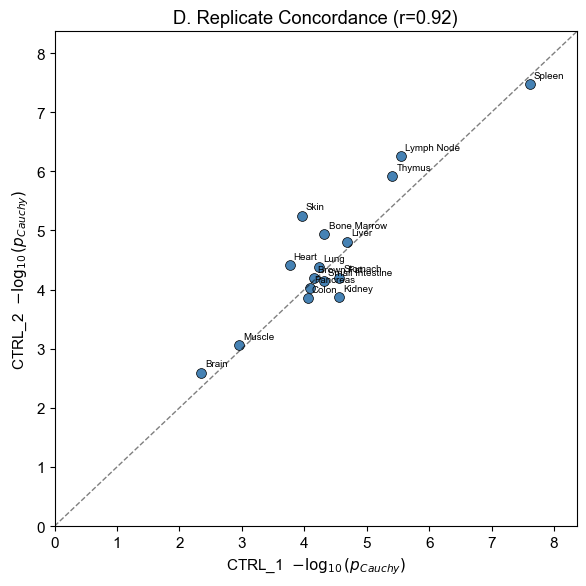

In [6]:
# Cell 7: Panel D — Replicate concordance (CTRL_1 vs CTRL_2)
from scipy.stats import pearsonr

ctrl1_min = cauchy[cauchy['sample'] == 'CTRL_1'].groupby('organ')['p_cauchy'].min()
ctrl2_min = cauchy[cauchy['sample'] == 'CTRL_2'].groupby('organ')['p_cauchy'].min()
rep = pd.DataFrame({'CTRL_1': -np.log10(ctrl1_min), 'CTRL_2': -np.log10(ctrl2_min)}).dropna()

r, pval = pearsonr(rep['CTRL_1'], rep['CTRL_2'])
print(f'Pearson r = {r:.3f}, p = {pval:.2e}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(rep['CTRL_1'], rep['CTRL_2'], s=50, c='steelblue', edgecolors='black', linewidths=0.5)
for org in rep.index:
    ax.annotate(org, (rep.loc[org, 'CTRL_1'], rep.loc[org, 'CTRL_2']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3),
                textcoords='offset points')
lim_max = max(rep['CTRL_1'].max(), rep['CTRL_2'].max()) * 1.1
ax.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.5, linewidth=1)
ax.set_xlabel('CTRL_1  $-\\log_{10}(p_{Cauchy})$')
ax.set_ylabel('CTRL_2  $-\\log_{10}(p_{Cauchy})$')
ax.set_title(f'D. Replicate Concordance (r={r:.2f})')
ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1D_replicate_concordance.png', dpi=300, bbox_inches='tight')
plt.show()


Brain annotations: 8, Bonferroni: 2.20


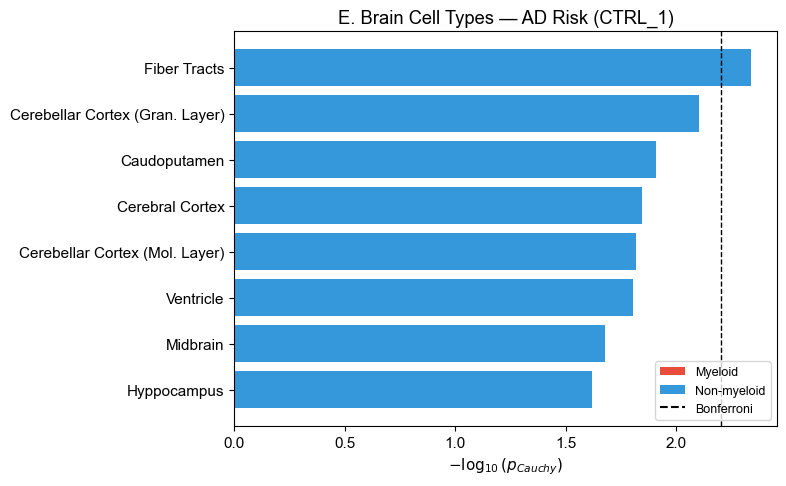

In [7]:
# Cell 8: Panel E — Brain cell type barplot (CTRL_1)
brain_ctrl1 = cauchy_ctrl1[cauchy_ctrl1['organ'] == 'Brain'].copy()
brain_ctrl1['logp'] = -np.log10(brain_ctrl1['p_cauchy'])
brain_ctrl1 = brain_ctrl1.sort_values('logp', ascending=True)

myeloid_kw = ['myeloid', 'macrophage', 'microgl', 'monocyte', 'kupffer', 'dendri']
brain_ctrl1['is_myeloid'] = brain_ctrl1['annotation'].str.lower().apply(
    lambda x: any(k in x for k in myeloid_kw))
brain_colors = ['#e74c3c' if m else '#3498db' for m in brain_ctrl1['is_myeloid']]

n_annot_brain = len(brain_ctrl1)
bonf_brain = -np.log10(0.05 / n_annot_brain)
print(f'Brain annotations: {n_annot_brain}, Bonferroni: {bonf_brain:.2f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(brain_ctrl1['annotation'], brain_ctrl1['logp'], color=brain_colors)
ax.axvline(bonf_brain, color='black', linestyle='--', linewidth=1,
           label=f'Bonferroni (p<0.05/{n_annot_brain})')
ax.set_xlabel('$-\\log_{10}(p_{Cauchy})$')
ax.set_title('E. Brain Cell Types — AD Risk (CTRL_1)')
# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Myeloid'),
                   Patch(facecolor='#3498db', label='Non-myeloid'),
                   plt.Line2D([0], [0], color='black', linestyle='--', label='Bonferroni')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1E_brain_celltypes.png', dpi=300, bbox_inches='tight')
plt.show()


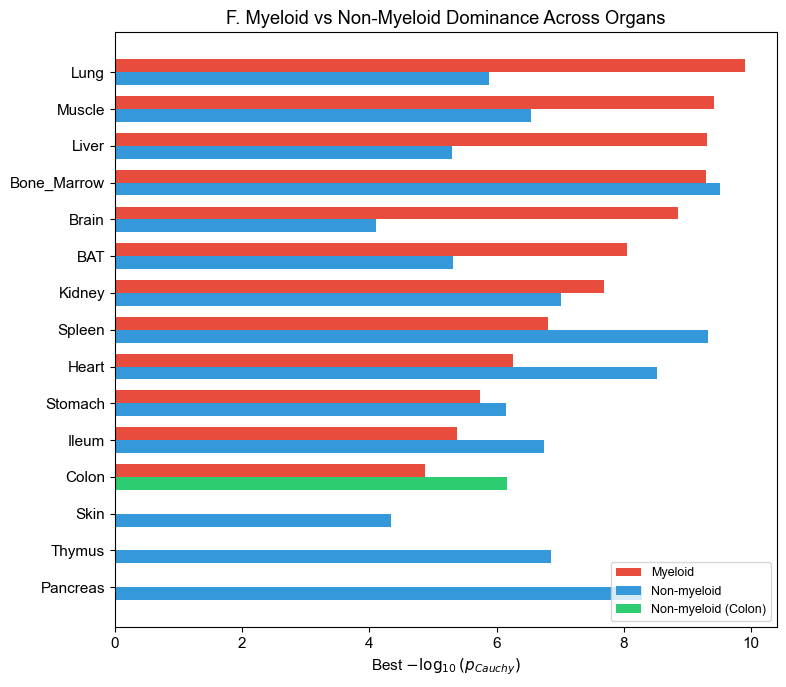

In [8]:
# Cell 9: Panel F — All organs myeloid dominance (from age data)
myeloid_kw = ['myeloid', 'macrophage', 'microgl', 'monocyte', 'kupffer', 'dendri']

age_cauchy['is_myeloid'] = age_cauchy['annotation'].str.lower().apply(
    lambda x: any(k in str(x) for k in myeloid_kw))

# For each organ: best myeloid and best non-myeloid -logp
organ_myeloid = []
for org in sorted(age_cauchy['organ'].unique()):
    sub = age_cauchy[age_cauchy['organ'] == org]
    mye = sub[sub['is_myeloid']]
    non_mye = sub[~sub['is_myeloid']]
    best_mye = -np.log10(mye['p_cauchy'].min()) if len(mye) > 0 else 0
    best_non = -np.log10(non_mye['p_cauchy'].min()) if len(non_mye) > 0 else 0
    organ_myeloid.append({'organ': org, 'Myeloid': best_mye, 'Non-myeloid': best_non})

mye_df = pd.DataFrame(organ_myeloid).set_index('organ')
mye_df = mye_df.sort_values('Myeloid', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(mye_df))
h = 0.35
# Color: red for myeloid, green for Colon non-myeloid (where non-myeloid wins), blue otherwise
mye_colors = ['#e74c3c'] * len(mye_df)
non_colors = []
for org in mye_df.index:
    if org == 'Colon':
        non_colors.append('#2ecc71')
    else:
        non_colors.append('#3498db')

ax.barh(y + h/2, mye_df['Myeloid'], h, color=mye_colors, label='Myeloid')
ax.barh(y - h/2, mye_df['Non-myeloid'], h, color=non_colors, label='Non-myeloid')
ax.set_yticks(y)
ax.set_yticklabels(mye_df.index)
ax.set_xlabel('Best $-\\log_{10}(p_{Cauchy})$')
ax.set_title('F. Myeloid vs Non-Myeloid Dominance Across Organs')
legend_elements = [Patch(facecolor='#e74c3c', label='Myeloid'),
                   Patch(facecolor='#3498db', label='Non-myeloid'),
                   Patch(facecolor='#2ecc71', label='Non-myeloid (Colon)')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1F_myeloid_dominance.png', dpi=300, bbox_inches='tight')
plt.show()


Valid age rows: 1402, months range: 1-30


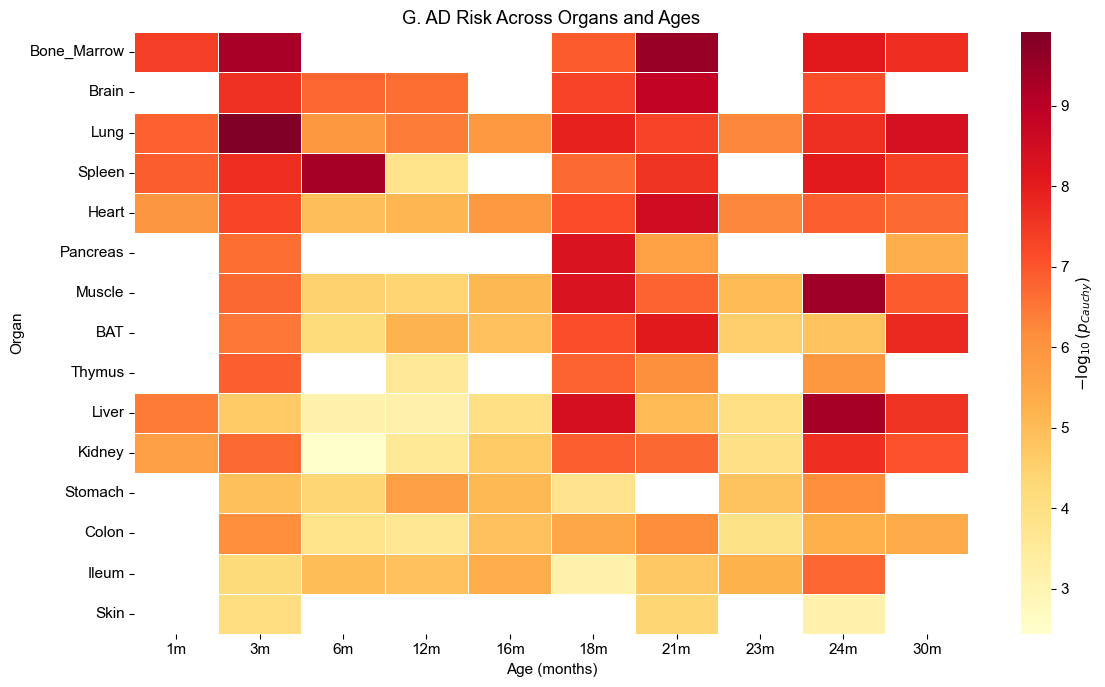

In [9]:
# Cell 10: Panel G — Organ x age heatmap
def age_to_months(age_str):
    """Convert mixed age formats to numeric months."""
    age_str = str(age_str).strip()
    m = re.match(r'(\d+)_?months?', age_str)
    if m:
        return int(m.group(1))
    m = re.match(r'(\d+)m$', age_str)
    if m:
        return int(m.group(1))
    return None

age_cauchy['months'] = age_cauchy['age'].apply(age_to_months)
age_valid = age_cauchy.dropna(subset=['months']).copy()
age_valid['months'] = age_valid['months'].astype(int)
print(f'Valid age rows: {len(age_valid)}, months range: {age_valid["months"].min()}-{age_valid["months"].max()}')

# For each organ-age: min p_cauchy -> -logp
heatmap_data = age_valid.groupby(['organ', 'months'])['p_cauchy'].min().reset_index()
heatmap_data['logp'] = -np.log10(heatmap_data['p_cauchy'])

# Pivot
hm_pivot = heatmap_data.pivot_table(index='organ', columns='months', values='logp')
hm_pivot = hm_pivot.reindex(columns=sorted(hm_pivot.columns))
# Sort organs by mean logp
hm_pivot = hm_pivot.loc[hm_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(hm_pivot, cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': '$-\\log_{10}(p_{Cauchy})$'},
            xticklabels=[f'{int(c)}m' for c in hm_pivot.columns])
ax.set_xlabel('Age (months)')
ax.set_ylabel('Organ')
ax.set_title('G. AD Risk Across Organs and Ages')
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig1G_organ_age_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


Saved composite: figures/paper1/Fig1_wholebody_atlas.png


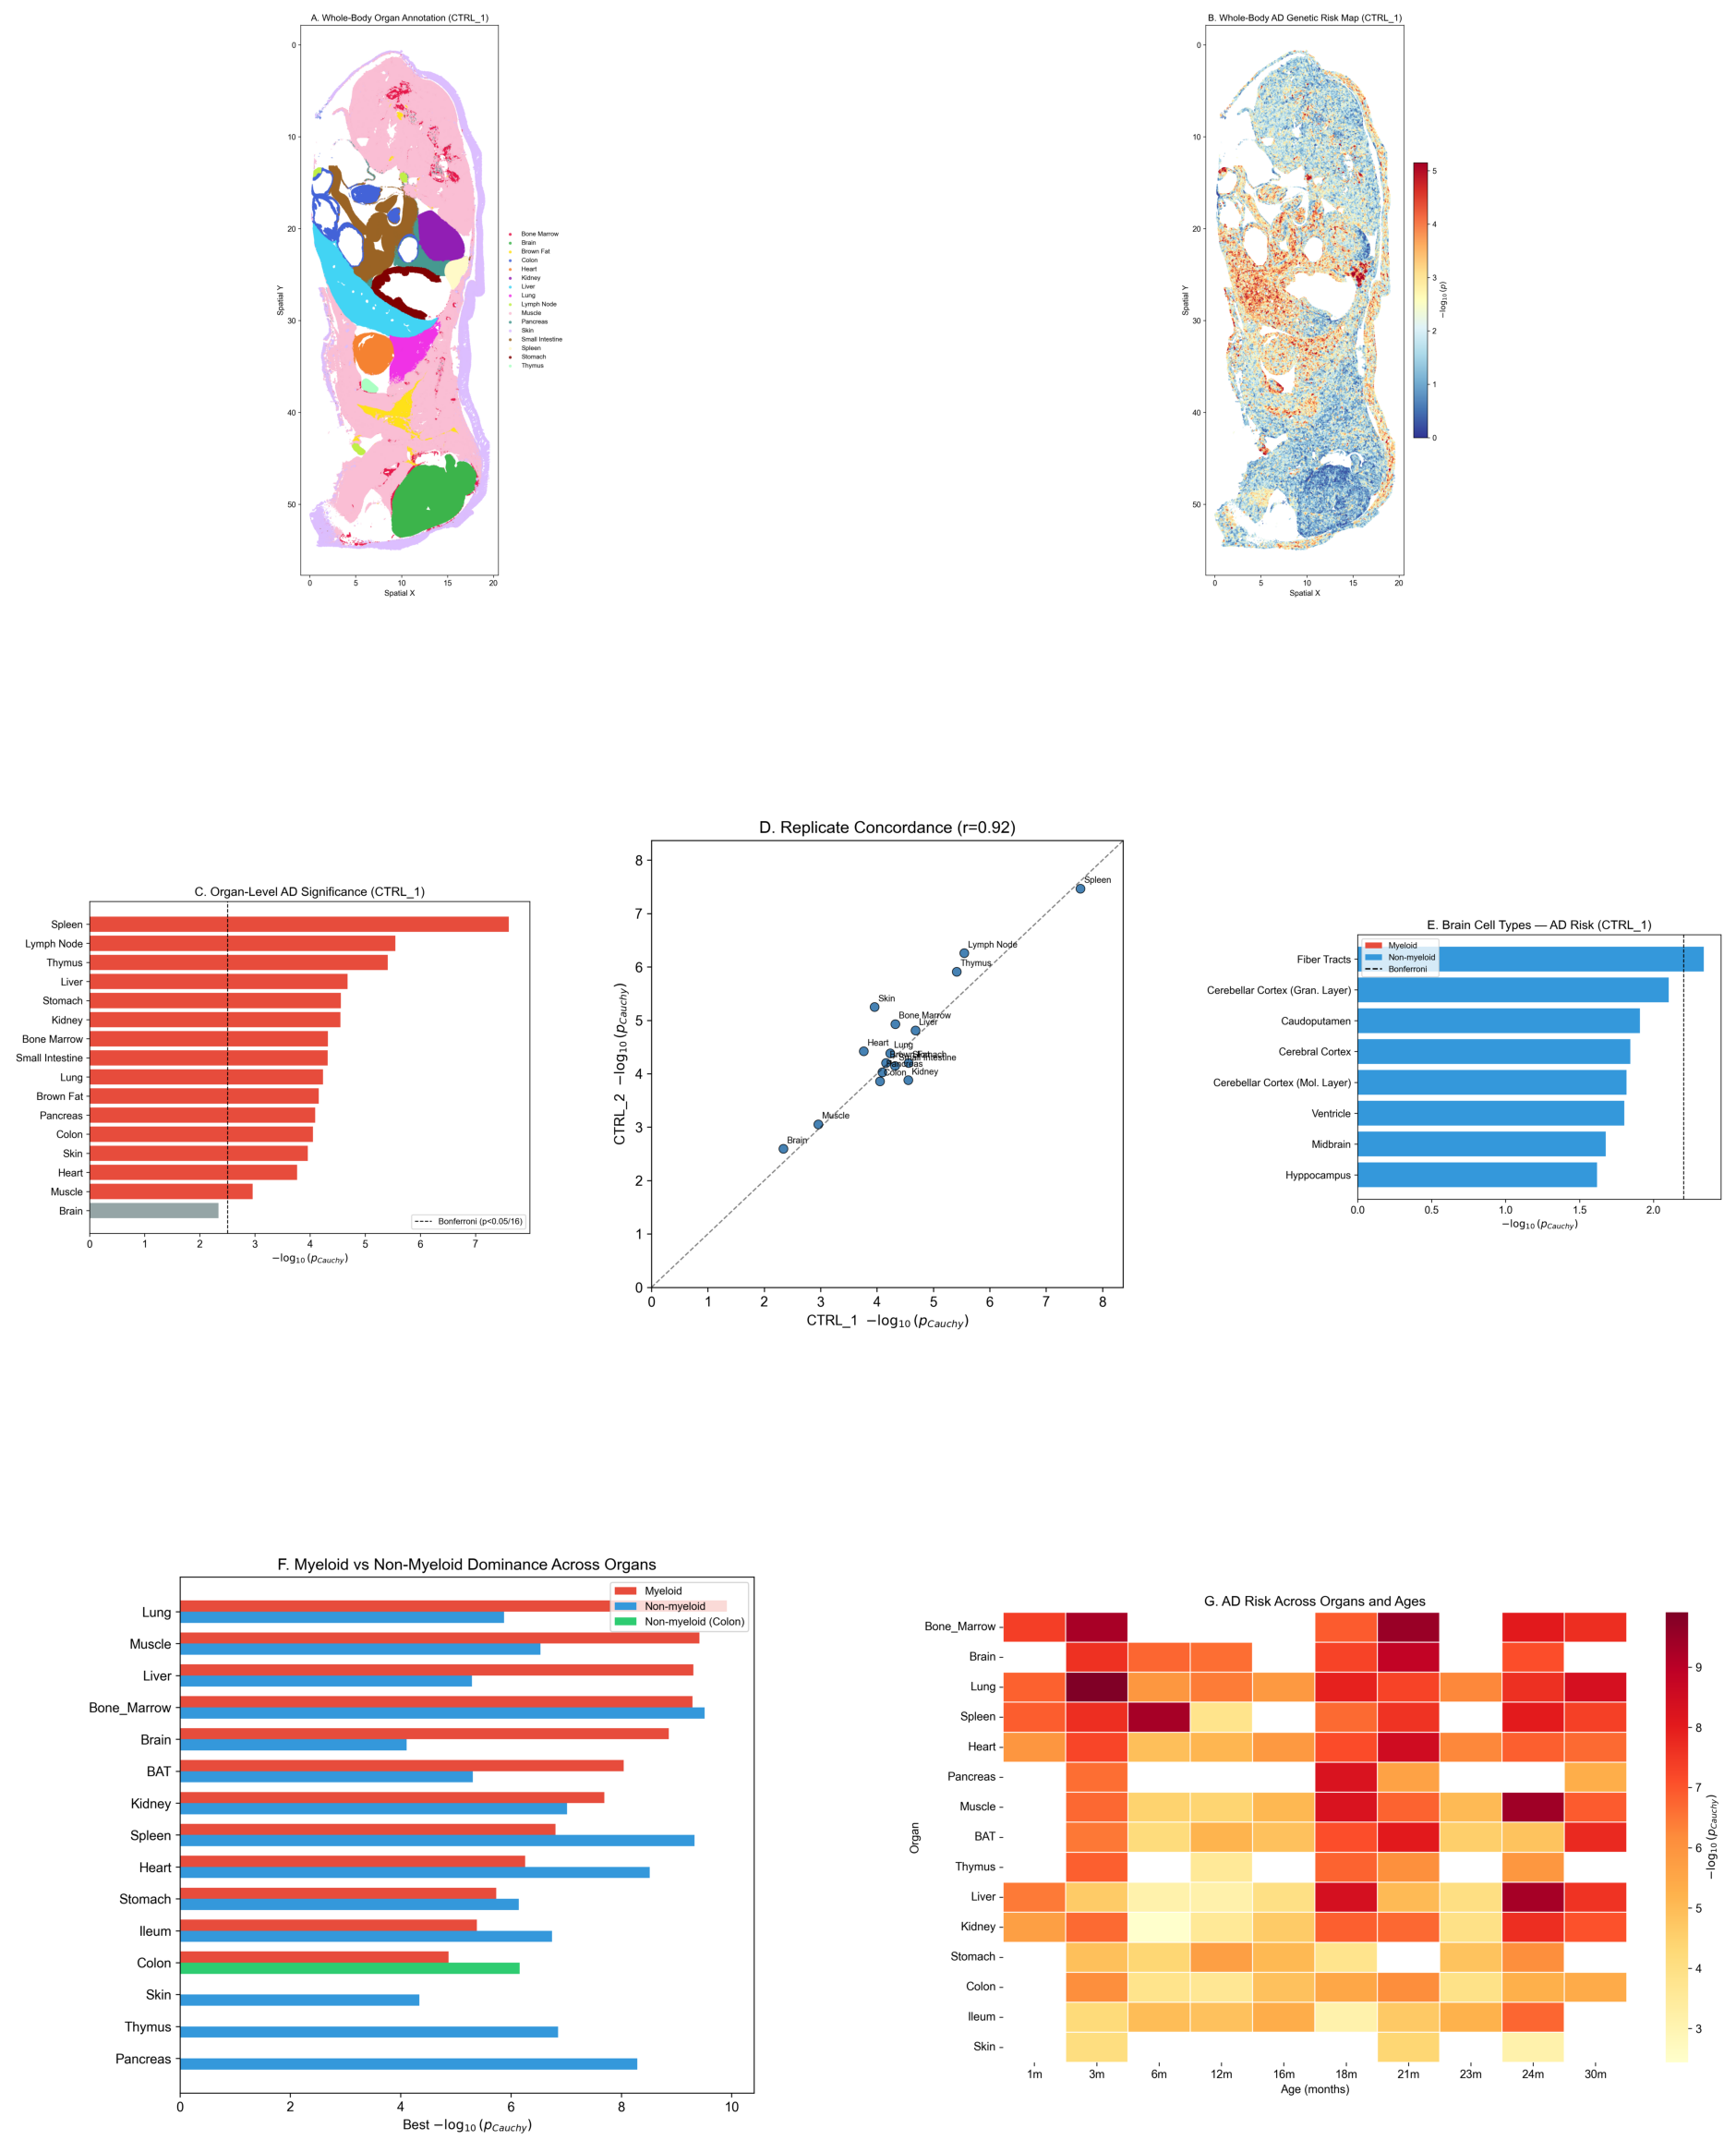

Done!


In [10]:
# Cell 11: Save composite figure
from matplotlib.image import imread

panel_files = {
    'A': f'{BASE}/figures/paper1/Fig1A_organ_annotation.png',
    'B': f'{BASE}/figures/paper1/Fig1B_risk_map.png',
    'C': f'{BASE}/figures/paper1/Fig1C_organ_barplot.png',
    'D': f'{BASE}/figures/paper1/Fig1D_replicate_concordance.png',
    'E': f'{BASE}/figures/paper1/Fig1E_brain_celltypes.png',
    'F': f'{BASE}/figures/paper1/Fig1F_myeloid_dominance.png',
    'G': f'{BASE}/figures/paper1/Fig1G_organ_age_heatmap.png',
}

# Composite: 3 rows
# Row 1: A, B (tall panels)
# Row 2: C, D, E
# Row 3: F, G
fig = plt.figure(figsize=(24, 30))
gs = fig.add_gridspec(3, 6, hspace=0.3, wspace=0.3)

panels_layout = [
    ('A', gs[0, 0:3]),
    ('B', gs[0, 3:6]),
    ('C', gs[1, 0:2]),
    ('D', gs[1, 2:4]),
    ('E', gs[1, 4:6]),
    ('F', gs[2, 0:3]),
    ('G', gs[2, 3:6]),
]

for label, spec in panels_layout:
    ax = fig.add_subplot(spec)
    img = imread(panel_files[label])
    ax.imshow(img)
    ax.axis('off')

fig.savefig(f'{BASE}/figures/paper1/Fig1_wholebody_atlas.png', dpi=200, bbox_inches='tight',
            facecolor='white')
print(f'Saved composite: {BASE}/figures/paper1/Fig1_wholebody_atlas.png')
plt.show()
print('Done!')
